# Crop Recommendation


### **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### **Loading Data**

In [50]:
crop = pd.read_csv('Augmented_Crop_recommendation.csv')
crop.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


### **Exploratory Data Analysis (EDA)**

In [51]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46200 entries, 0 to 46199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            46200 non-null  float64
 1   P            46200 non-null  float64
 2   K            46200 non-null  float64
 3   temperature  46200 non-null  float64
 4   humidity     46200 non-null  float64
 5   ph           46200 non-null  float64
 6   rainfall     46200 non-null  float64
 7   label        46200 non-null  object 
dtypes: float64(7), object(1)
memory usage: 2.8+ MB


In [52]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,46200.000000,46200.000000,46200.000000,46200.000000,46200.000000,46200.000000,46200.000000
mean,50.306791,53.028307,47.766297,25.621888,71.462477,6.463923,103.448992
std,36.909797,32.944926,50.627718,4.895035,22.197127,0.699343,54.920300
min,-4.981243,-0.443264,-0.606844,8.771441,12.122534,3.460442,12.719780
25%,20.797736,27.000000,20.000000,22.730258,60.144909,5.991090,64.676148
50%,36.000000,51.000000,31.000000,25.601540,80.524653,6.438279,94.903816
75%,84.685054,67.887611,48.619458,28.522964,89.750701,6.873873,124.044238
max,143.365808,148.474362,211.089125,44.011620,101.564259,9.994929,301.874963


In [53]:
crop.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [54]:
crop.shape

(46200, 8)

In [55]:
crop['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [56]:
crop['label'].nunique()

22

In [57]:
crop['label'].value_counts()

label
rice           2100
maize          2100
jute           2100
cotton         2100
coconut        2100
papaya         2100
orange         2100
apple          2100
muskmelon      2100
watermelon     2100
grapes         2100
mango          2100
banana         2100
pomegranate    2100
lentil         2100
blackgram      2100
mungbean       2100
mothbeans      2100
pigeonpeas     2100
kidneybeans    2100
chickpea       2100
coffee         2100
Name: count, dtype: int64

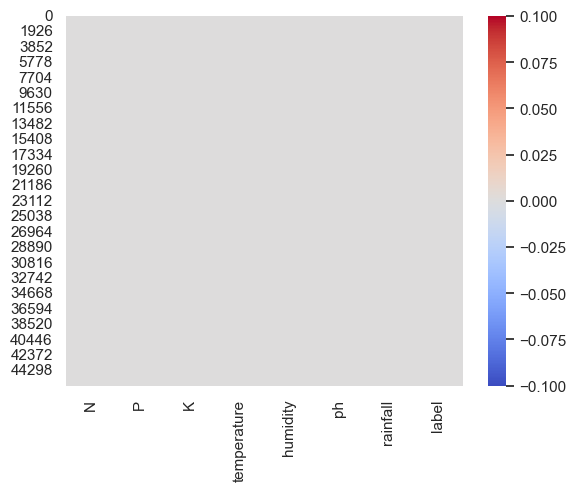

In [58]:
sns.heatmap(crop.isnull(), cmap="coolwarm")
plt.show()

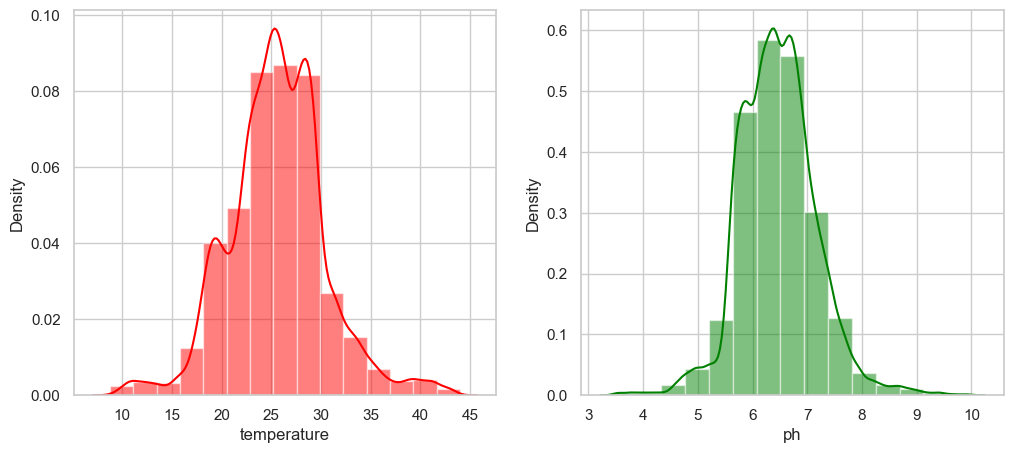

In [59]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.distplot(crop['temperature'],color="red",bins=15,hist_kws={'alpha':0.5})
plt.subplot(1,2,2)
sns.distplot(crop['ph'],color="green",bins=15,hist_kws={'alpha':0.5})
plt.show()

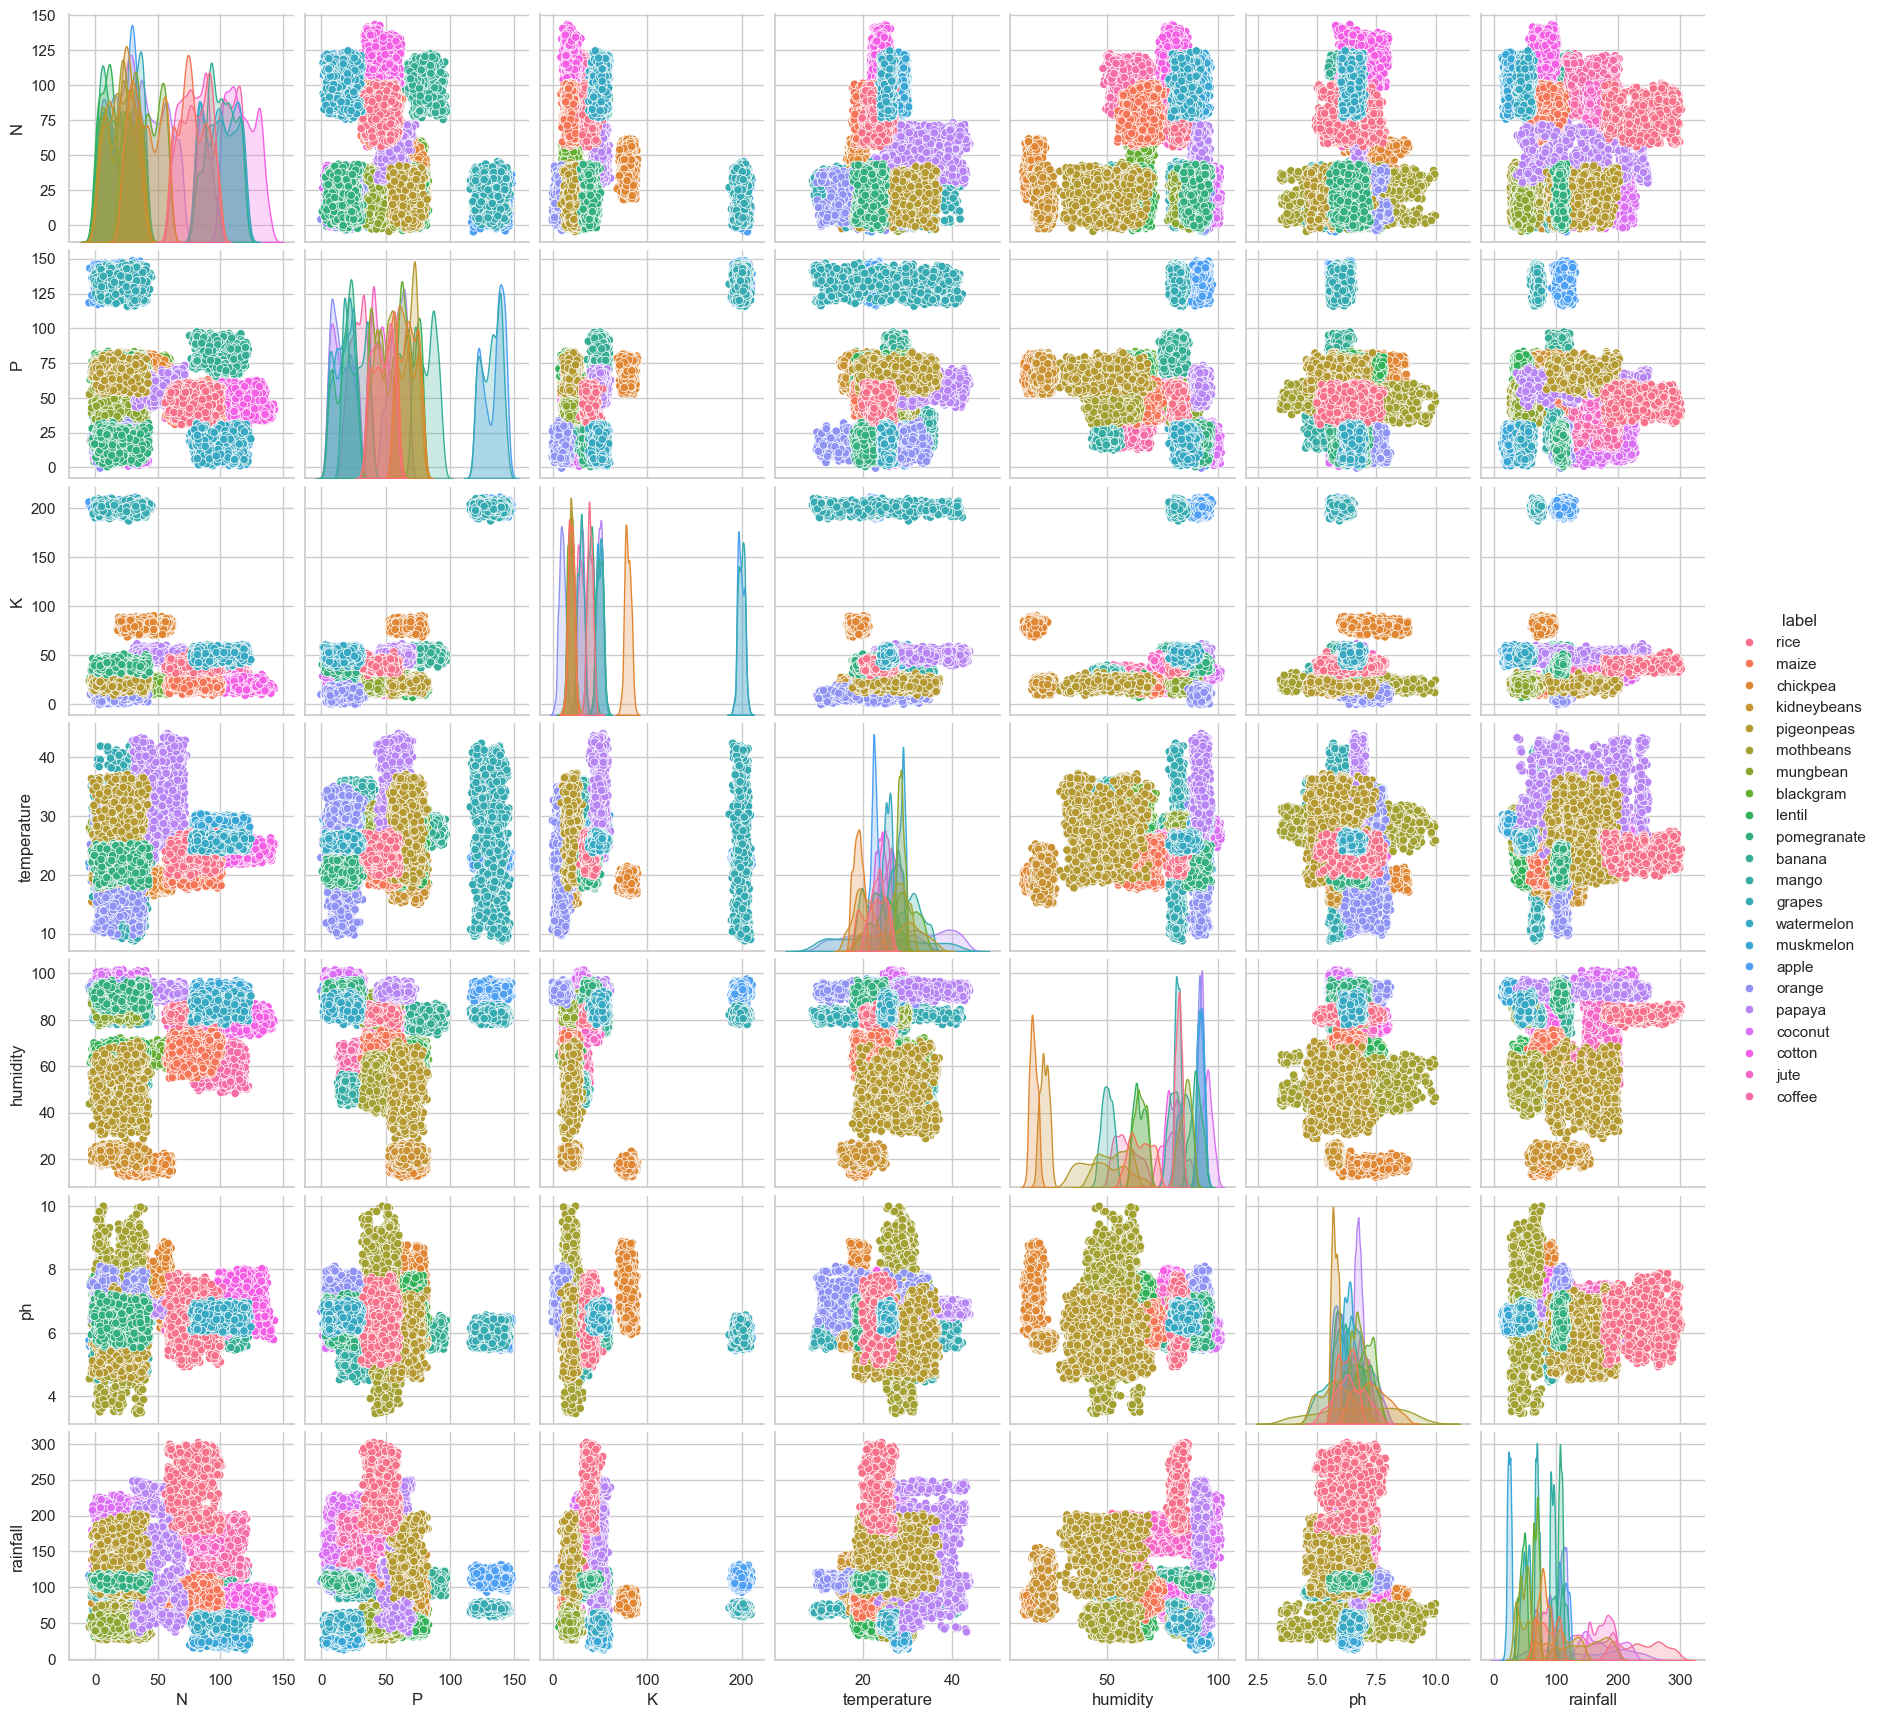

In [60]:
sns.pairplot(crop,hue='label')
plt.show()

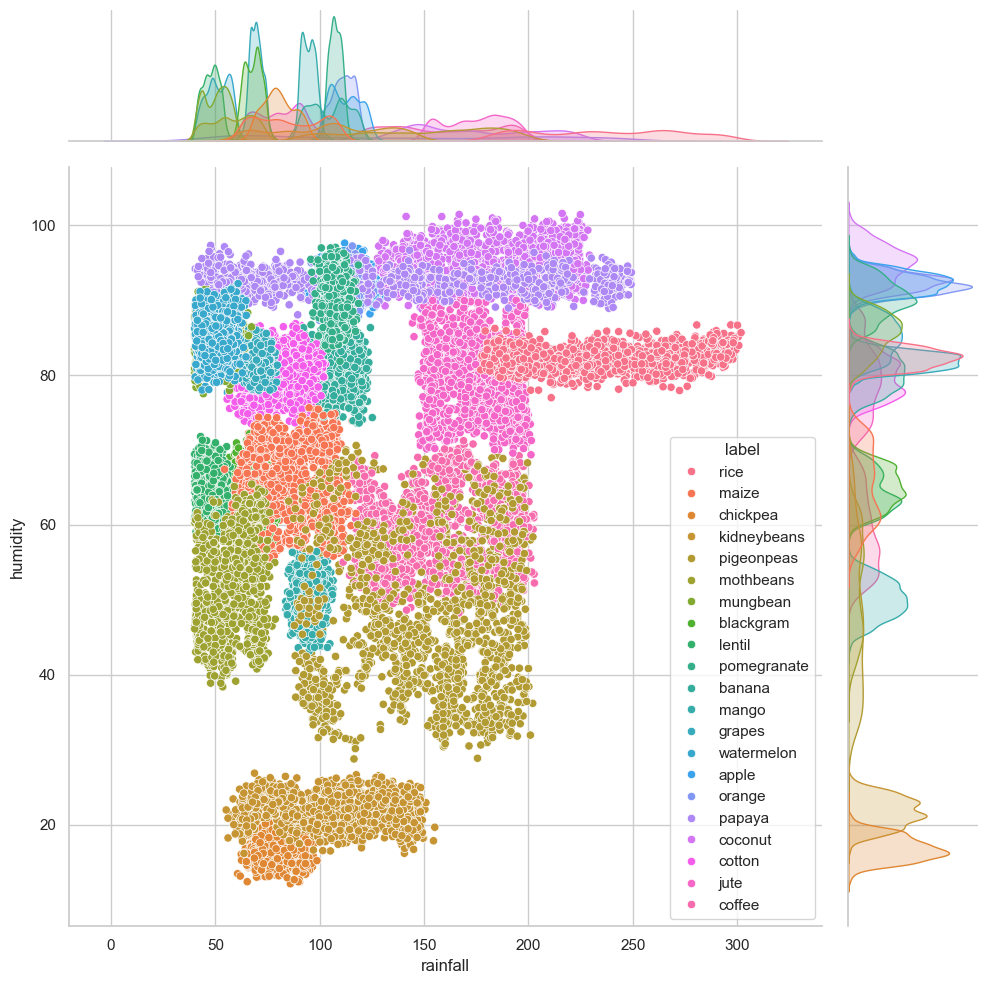

In [61]:
sns.jointplot(x="rainfall",y="humidity",data=crop[(crop['temperature']<40) &
                                                  (crop['rainfall']>40)],height=10,hue="label")
plt.show()

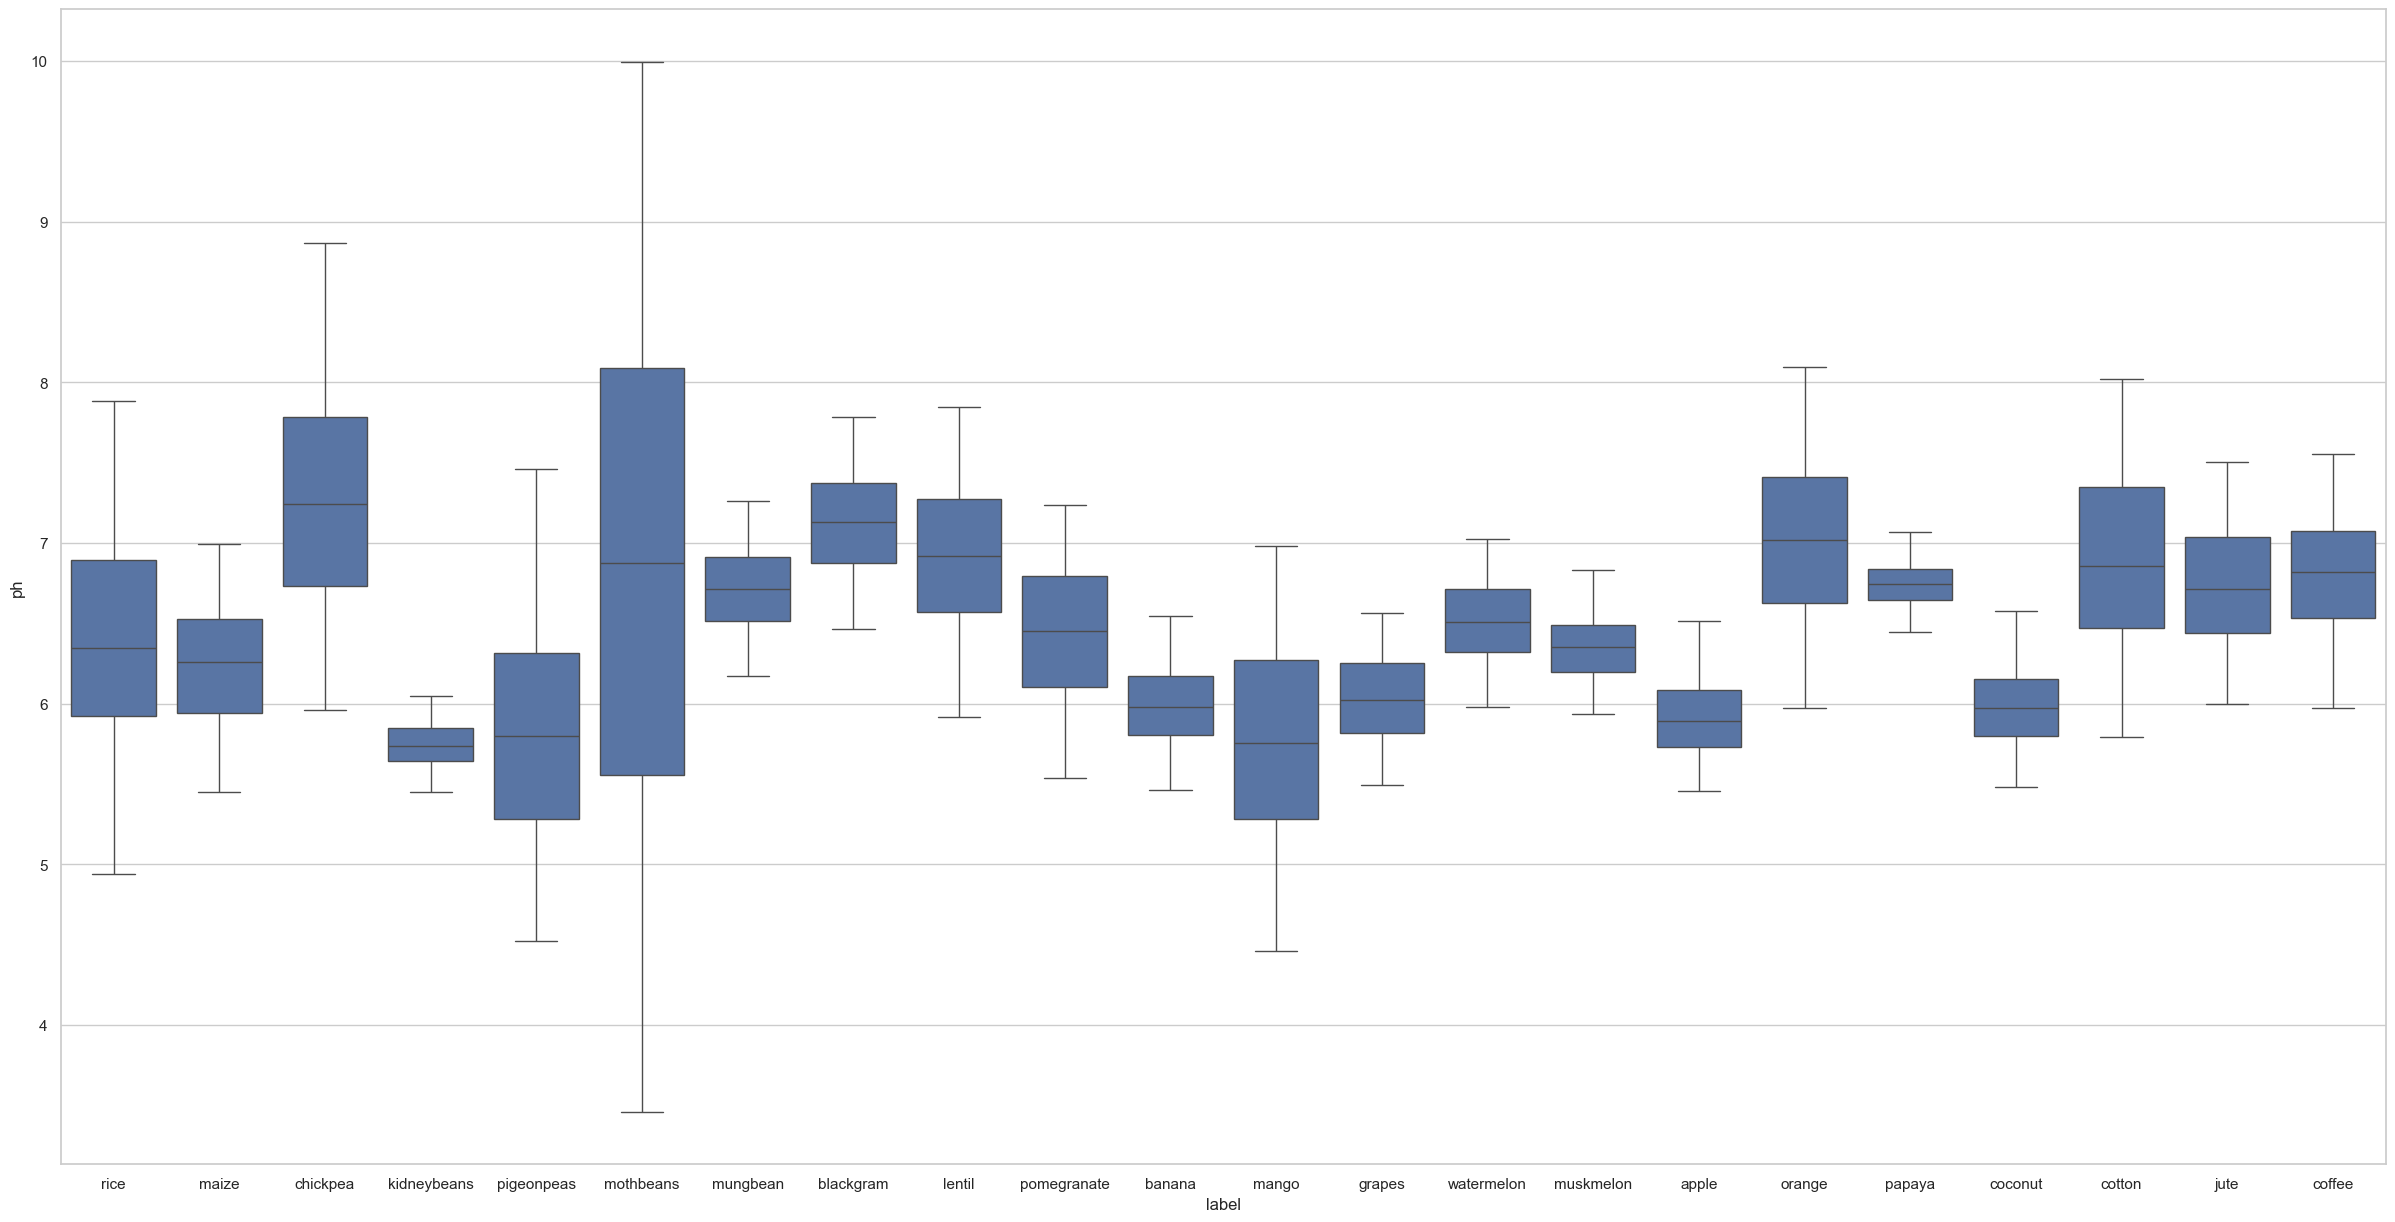

In [62]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(30,15))
sns.boxplot(x='label',y='ph',data=crop)
plt.show()

In [63]:
f = list(crop.columns)
f.remove('label')
features=crop[f]

In [64]:
target = crop['label']

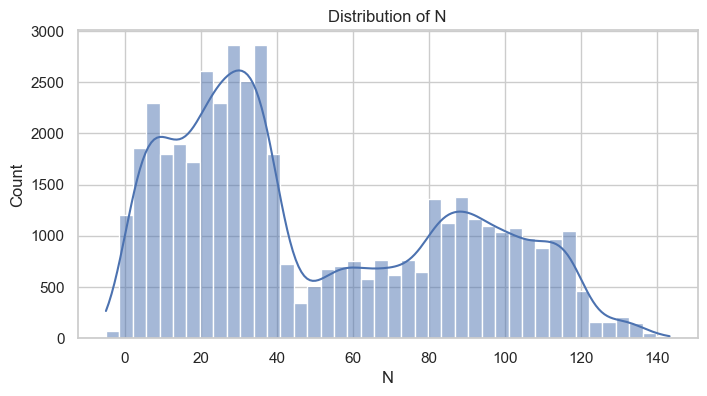

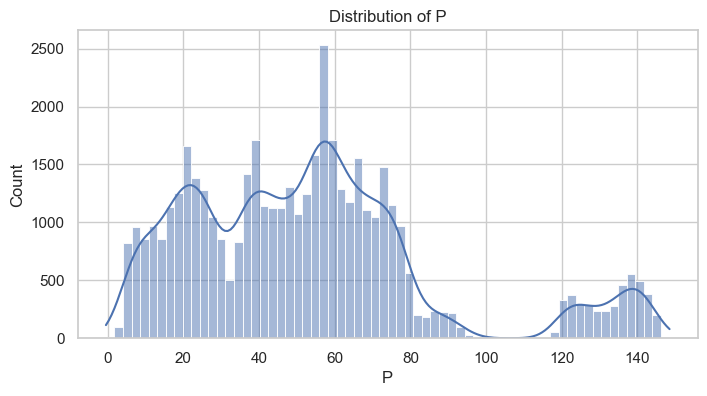

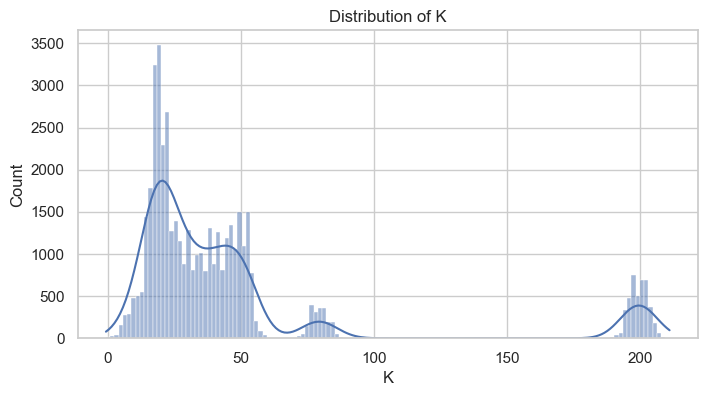

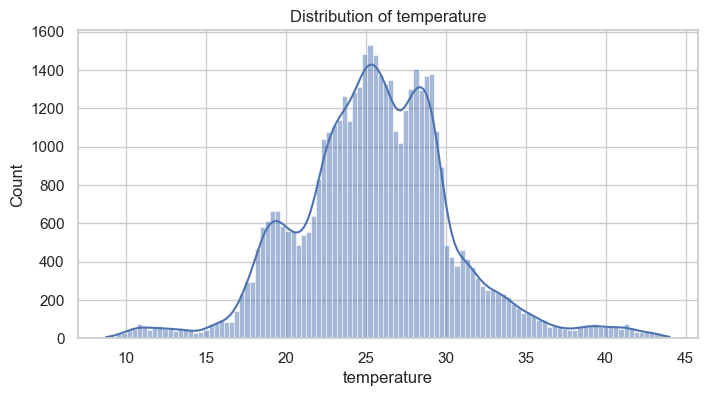

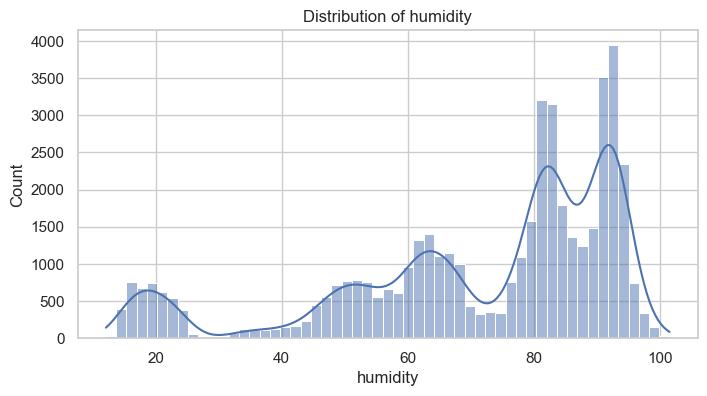

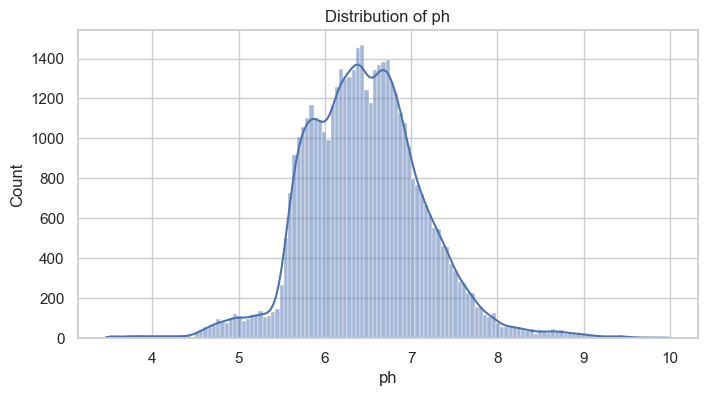

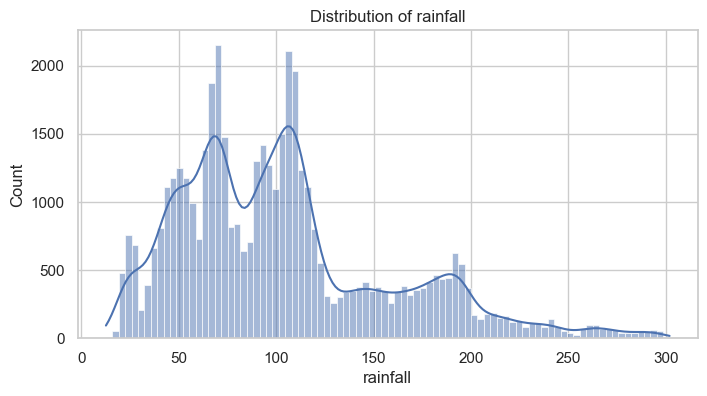

In [65]:
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(crop[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

                  N             P             K   temperature      humidity  \
count  46200.000000  46200.000000  46200.000000  46200.000000  46200.000000   
mean      50.306791     53.028307     47.766297     25.621888     71.462477   
std       36.909797     32.944926     50.627718      4.895035     22.197127   
min       -4.981243     -0.443264     -0.606844      8.771441     12.122534   
25%       20.797736     27.000000     20.000000     22.730258     60.144909   
50%       36.000000     51.000000     31.000000     25.601540     80.524653   
75%       84.685054     67.887611     48.619458     28.522964     89.750701   
max      143.365808    148.474362    211.089125     44.011620    101.564259   

                 ph      rainfall  
count  46200.000000  46200.000000  
mean       6.463923    103.448992  
std        0.699343     54.920300  
min        3.460442     12.719780  
25%        5.991090     64.676148  
50%        6.438279     94.903816  
75%        6.873873    124.044238  


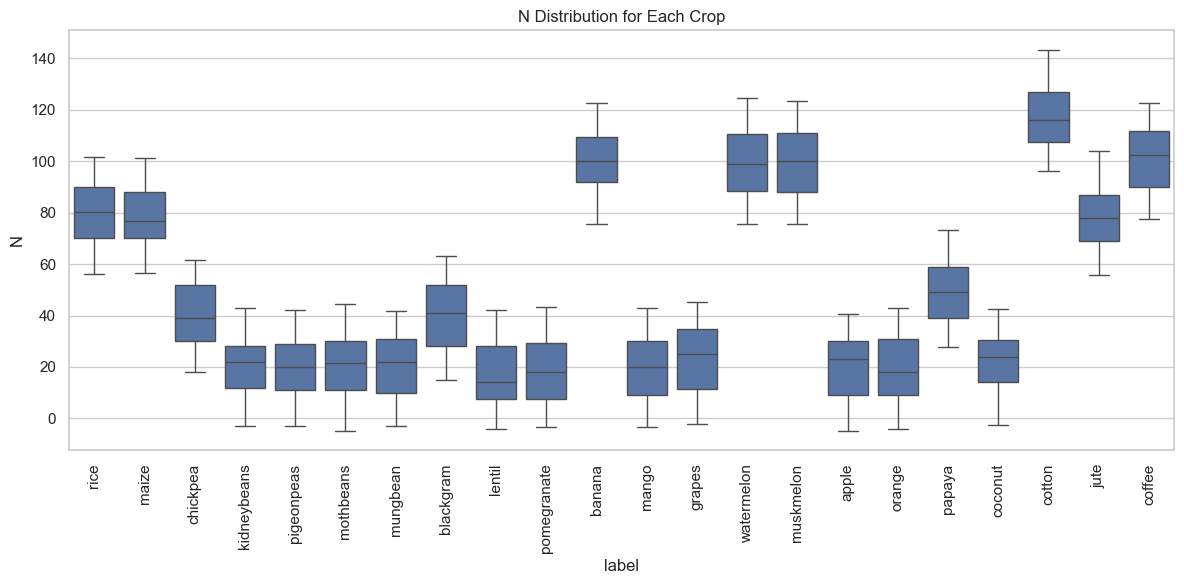

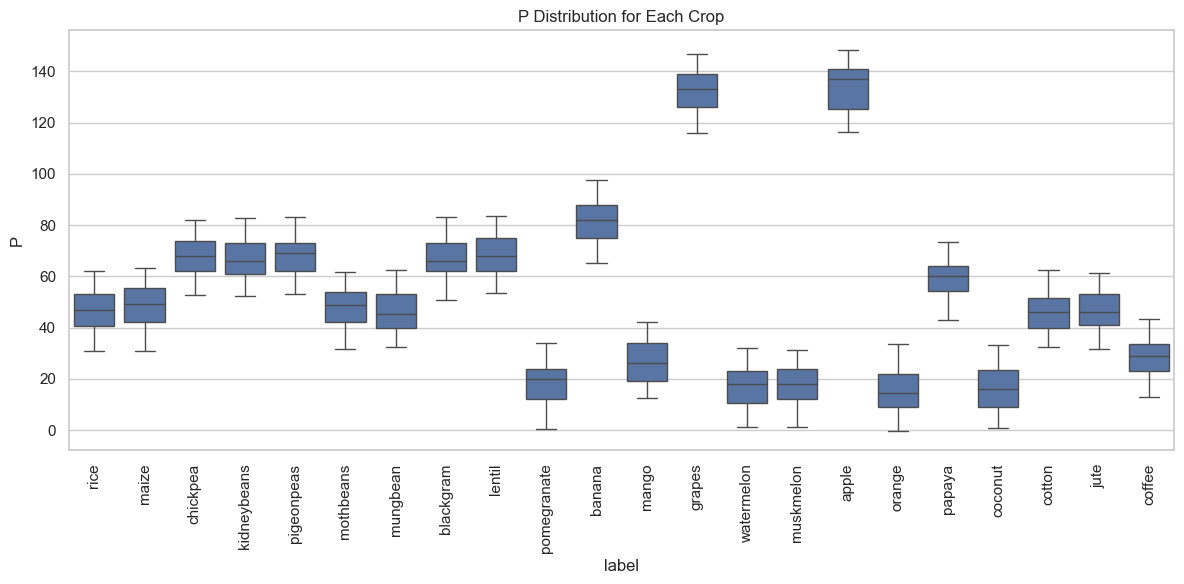

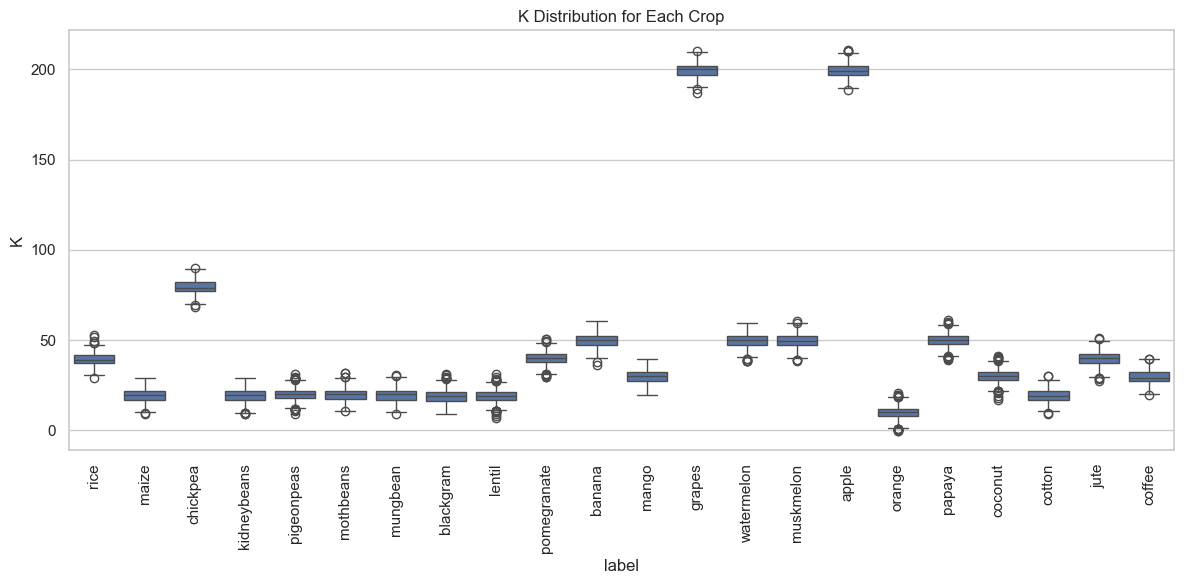

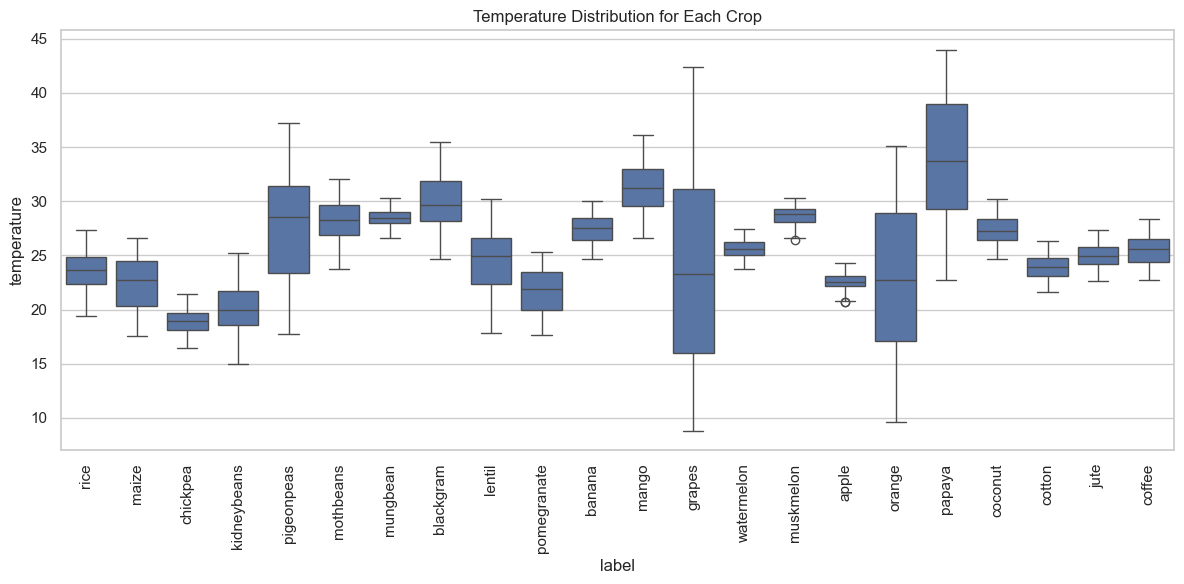

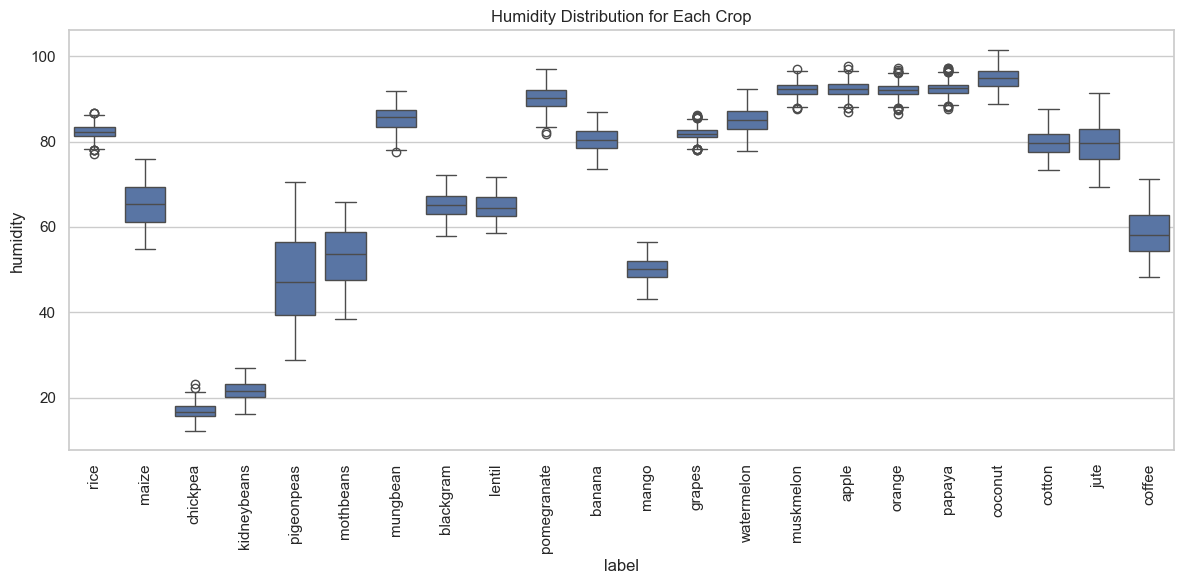

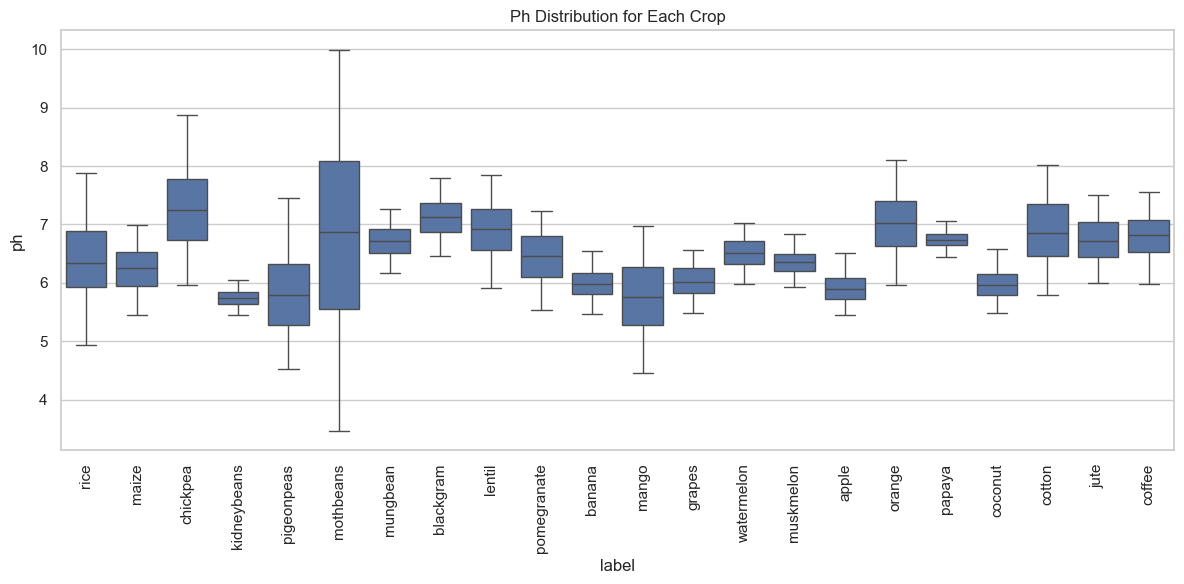

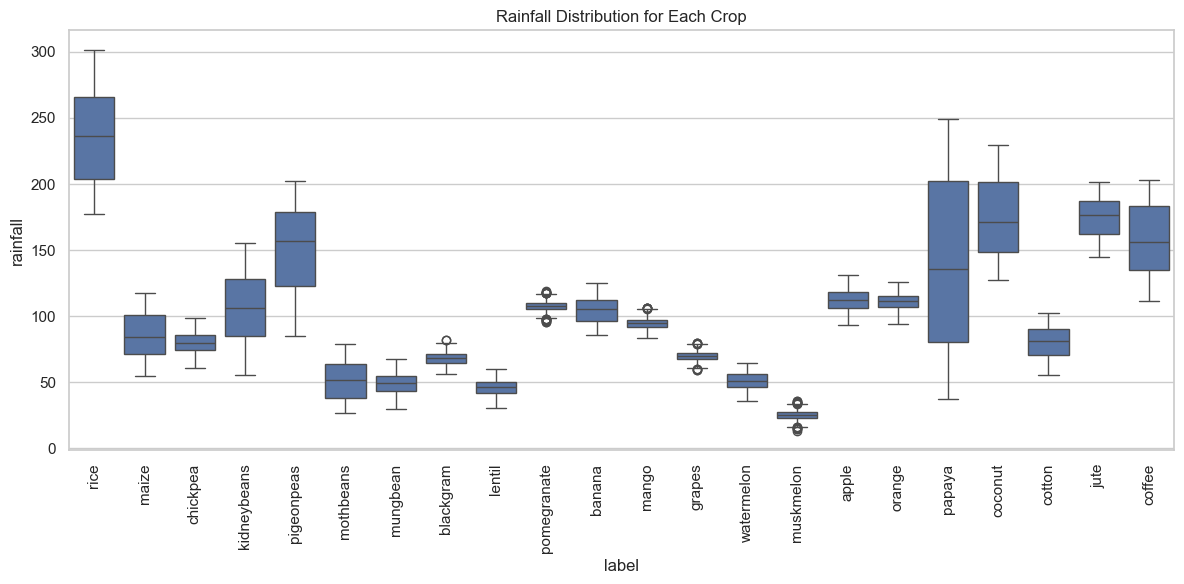

In [66]:
crop_conditions = crop.describe()
print(crop_conditions)
crop_conditions.to_csv('crop_conditions.csv')
for feature in features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='label', y=feature, data=crop)
    plt.title(f"{feature.capitalize()} Distribution for Each Crop")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

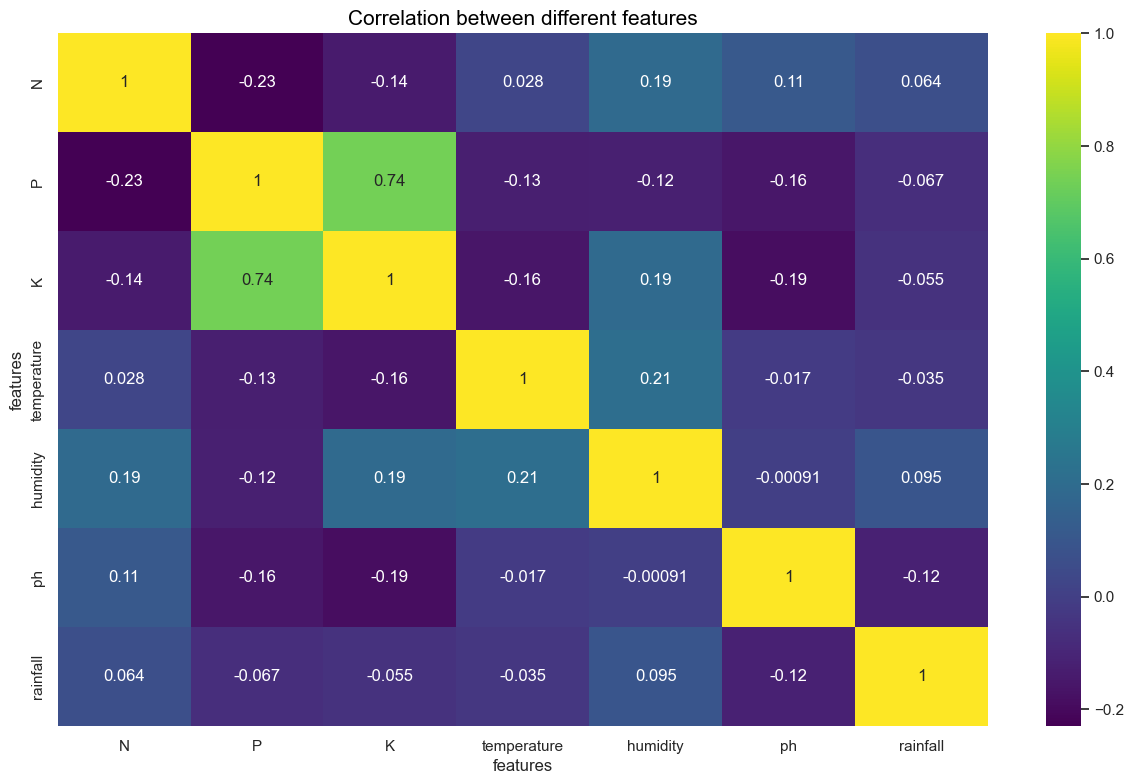

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(15, 9))
sns.heatmap(features.corr(), annot=True,cmap='viridis')
ax.set(xlabel='features')
ax.set(ylabel='features')
plt.title('Correlation between different features', fontsize = 15, c='black')
plt.show()

In [68]:
crop_summary = pd.pivot_table(crop,index=['label'],aggfunc='mean')
crop_summary.head()

,K,N,P,humidity,ph,rainfall,temperature
label,,,,,,,
apple,199.375966,19.884675,133.806605,92.340316,5.916383,112.222302,22.590585
banana,49.796293,100.557265,81.719825,80.366210,5.982997,104.746591,27.451292
blackgram,18.854423,39.793097,67.072009,65.053746,7.125912,67.873871,29.964605
chickpea,79.489970,40.096834,67.663685,16.857338,7.291794,80.221589,18.925738
coconut,30.123373,21.933763,16.480040,94.892606,5.978070,174.665319,27.339976


In [1]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=crop_summary.index,
    y=crop_summary['N'],
    name='Nitrogen',
    marker_color='mediumvioletred'
))
fig.add_trace(go.Bar(
    x=crop_summary.index,
    y=crop_summary['P'],
    name='Phosphorous',
    marker_color='springgreen'
))
fig.add_trace(go.Bar(
    x=crop_summary.index,
    y=crop_summary['K'],
    name='Potash',
    marker_color='dodgerblue'
))

fig.update_layout(title="N-P-K values comparision between crops",
                  plot_bgcolor='white',
                  barmode='group',
                  xaxis_tickangle=-45)

fig.show()

NameError: name 'go' is not defined

### **Feature Selection**

In [87]:
features.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340


In [88]:
target.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

In [89]:
acc = []
model = []

In [90]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features,target,test_size = 0.2,random_state =2)

## **Modeling Classification Algorithms**

### **K-Nearest Neighbors**

In [91]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn.fit(x_train,y_train)

predicted_values = knn.predict(x_test)

x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('K Nearest Neighbours')
print("KNN Accuracy is: ", x)

print(classification_report(y_test,predicted_values))

KNN Accuracy is:  0.9985930735930736
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       411
      banana       1.00      1.00      1.00       374
   blackgram       1.00      1.00      1.00       392
    chickpea       1.00      1.00      1.00       436
     coconut       1.00      1.00      1.00       420
      coffee       1.00      1.00      1.00       438
      cotton       1.00      1.00      1.00       433
      grapes       1.00      1.00      1.00       453
        jute       0.99      0.99      0.99       420
 kidneybeans       1.00      1.00      1.00       425
      lentil       1.00      1.00      1.00       451
       maize       1.00      1.00      1.00       423
       mango       1.00      1.00      1.00       396
   mothbeans       1.00      1.00      1.00       437
    mungbean       1.00      1.00      1.00       402
   muskmelon       1.00      1.00      1.00       375
      orange       1.00      1.00      1.00 

In [92]:
score = cross_val_score(knn,features,target,cv=5)
print('Cross validation score: ',score)

Cross validation score:  [0.99989177 0.99891775 0.99902597 0.9969697  0.99761905]


In [93]:
knn_train_accuracy = knn.score(x_train,y_train)
print("knn_train_accuracy = ",knn.score(x_train,y_train))

knn_test_accuracy = knn.score(x_test,y_test)
print("knn_test_accuracy = ",knn.score(x_test,y_test))

knn_train_accuracy =  0.99883658008658
knn_test_accuracy =  0.9985930735930736


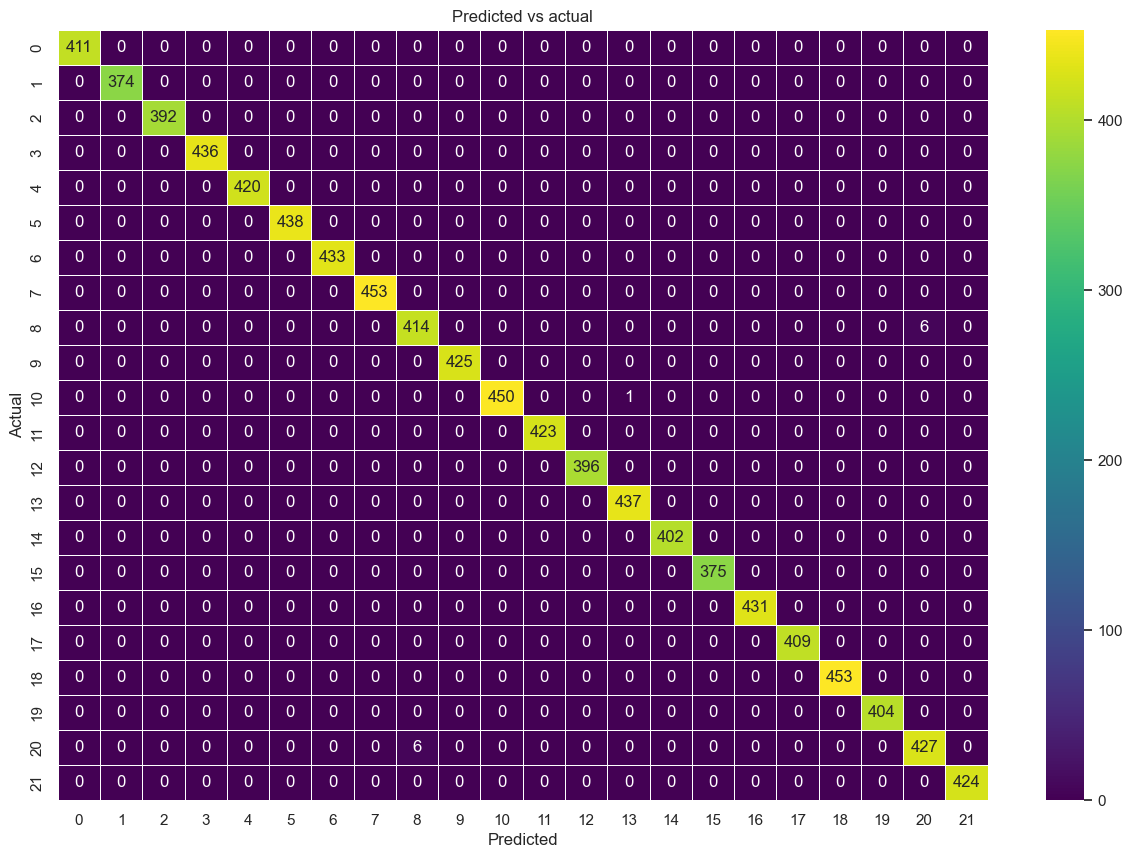

In [94]:
y_pred = knn.predict(x_test)
y_true = y_test

cm_knn = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_knn, annot=True, linewidth=0.5, fmt=".0f",cmap='viridis', ax = ax)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Predicted vs actual')
plt.show()

**Hyperparameter Tuning**

In [95]:
mean_acc = np.zeros(20)
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors = i).fit(x_train,y_train)
    yhat= knn.predict(x_test)
    mean_acc[i-1] = metrics.accuracy_score(y_test, yhat)
mean_acc

array([0.99848485, 0.9978355 , 0.9987013 , 0.99859307, 0.99859307,
       0.99837662, 0.99816017, 0.9982684 , 0.9982684 , 0.99848485,
       0.99859307, 0.99859307, 0.99859307, 0.99816017, 0.9982684 ,
       0.9982684 , 0.99837662, 0.99837662, 0.99848485, 0.99816017])

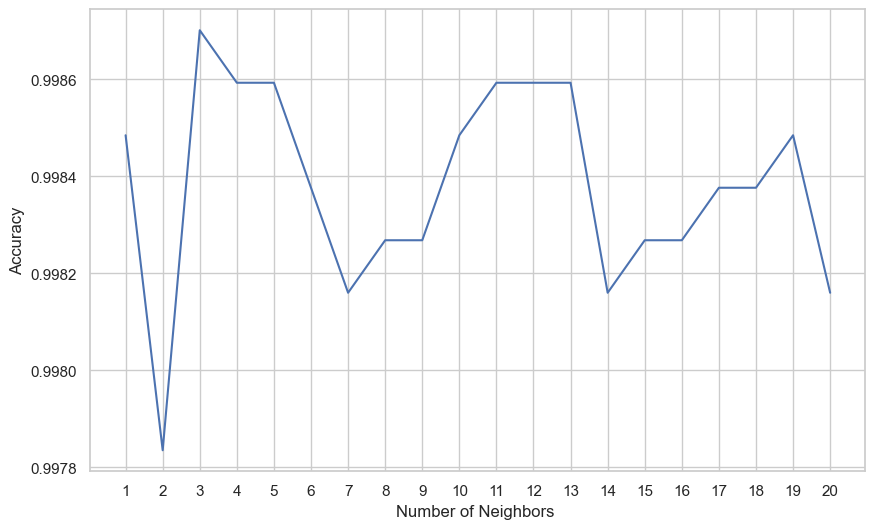

In [96]:
loc = np.arange(1,21,step=1.0)
plt.figure(figsize = (10, 6))
plt.plot(range(1,21), mean_acc)
plt.xticks(loc)
plt.xlabel('Number of Neighbors ')
plt.ylabel('Accuracy')
plt.show()

In [97]:
from sklearn.model_selection import GridSearchCV
grid_params = { 'n_neighbors' : [12,13,14,15,16,17,18],
               'weights' : ['uniform','distance'],
               'metric' : ['minkowski','euclidean','manhattan']}

In [98]:
gs = GridSearchCV(KNeighborsClassifier(), grid_params, verbose = 1, cv=3, n_jobs = -1)
g_res = gs.fit(x_train, y_train)

Fitting 3 folds for each of 42 candidates, totalling 126 fits


In [99]:
g_res.best_score_

0.9984036796536797

In [100]:
g_res.best_params_

{'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}

In [101]:
knn_1 = KNeighborsClassifier(n_neighbors = 12, weights = 'distance',algorithm = 'brute',metric = 'manhattan')
knn_1.fit(x_train, y_train)

KNeighborsClassifier(algorithm='brute', metric='manhattan', n_neighbors=12,
                     weights='distance')

In [102]:
knn_train_accuracy = knn_1.score(x_train,y_train)
print("knn_train_accuracy = ",knn_1.score(x_train,y_train))

knn_test_accuracy = knn_1.score(x_test,y_test)
print("knn_test_accuracy = ",knn_1.score(x_test,y_test))

knn_train_accuracy =  1.0
knn_test_accuracy =  0.999025974025974


### **Decision Tree**

In [103]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

DT.fit(x_train,y_train)

predicted_values = DT.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("Decision Tree's Accuracy is: ", x*100)

print(classification_report(y_test,predicted_values))

Decision Tree's Accuracy is:  92.96536796536796
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       411
      banana       1.00      0.98      0.99       374
   blackgram       0.70      0.98      0.82       392
    chickpea       1.00      1.00      1.00       436
     coconut       1.00      1.00      1.00       420
      coffee       0.90      1.00      0.95       438
      cotton       0.97      1.00      0.99       433
      grapes       1.00      1.00      1.00       453
        jute       0.00      0.00      0.00       420
 kidneybeans       1.00      1.00      1.00       425
      lentil       0.94      0.98      0.96       451
       maize       0.99      0.97      0.98       423
       mango       1.00      1.00      1.00       396
   mothbeans       0.98      0.57      0.72       437
    mungbean       1.00      1.00      1.00       402
   muskmelon       1.00      1.00      1.00       375
      orange       1.00      1.00

In [104]:
score = cross_val_score(DT, features, target,cv=5)
print('Cross validation score: ',score)

Cross validation score:  [0.93246753 0.93257576 0.92813853 0.90779221 0.90714286]


In [105]:
dt_train_accuracy = DT.score(x_train,y_train)
print("Training accuracy = ",DT.score(x_train,y_train))

dt_test_accuracy = DT.score(x_test,y_test)
print("Testing accuracy = ",DT.score(x_test,y_test))

Training accuracy =  0.9305735930735931
Testing accuracy =  0.9296536796536796


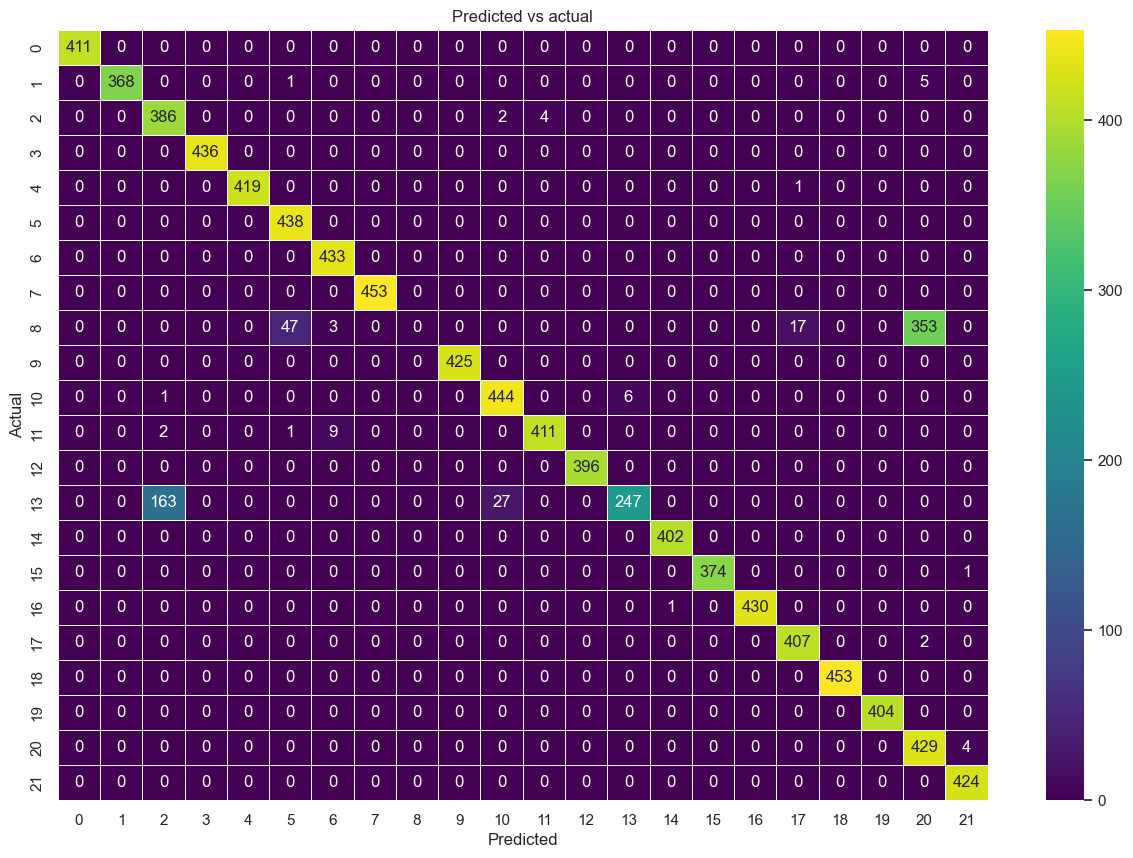

In [106]:
y_pred = DT.predict(x_test)
y_true = y_test

cm_dt = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_dt, annot=True, linewidth=0.5, fmt=".0f",  cmap='viridis', ax = ax)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Predicted vs actual')
plt.show()

### **Random Forest**

In [107]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(x_train,y_train)

predicted_values = RF.predict(x_test)

x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('RF')
print("Random Forest Accuracy is: ", x)

print(classification_report(y_test,predicted_values))

Random Forest Accuracy is:  0.9989177489177489
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       411
      banana       1.00      1.00      1.00       374
   blackgram       1.00      1.00      1.00       392
    chickpea       1.00      1.00      1.00       436
     coconut       1.00      1.00      1.00       420
      coffee       1.00      1.00      1.00       438
      cotton       1.00      1.00      1.00       433
      grapes       1.00      1.00      1.00       453
        jute       0.99      0.99      0.99       420
 kidneybeans       1.00      1.00      1.00       425
      lentil       1.00      1.00      1.00       451
       maize       1.00      1.00      1.00       423
       mango       1.00      1.00      1.00       396
   mothbeans       1.00      1.00      1.00       437
    mungbean       1.00      1.00      1.00       402
   muskmelon       1.00      1.00      1.00       375
      orange       1.00      1.00 

In [108]:
score = cross_val_score(RF,features,target,cv=5)
print('Cross validation score: ',score)

Cross validation score:  [0.99945887 0.99935065 0.9978355  0.99805195 0.99664502]


In [109]:
rf_train_accuracy = RF.score(x_train,y_train)
print("Training accuracy = ",RF.score(x_train,y_train))

rf_test_accuracy = RF.score(x_test,y_test)
print("Testing accuracy = ",RF.score(x_test,y_test))

Training accuracy =  0.9999729437229438
Testing accuracy =  0.9989177489177489


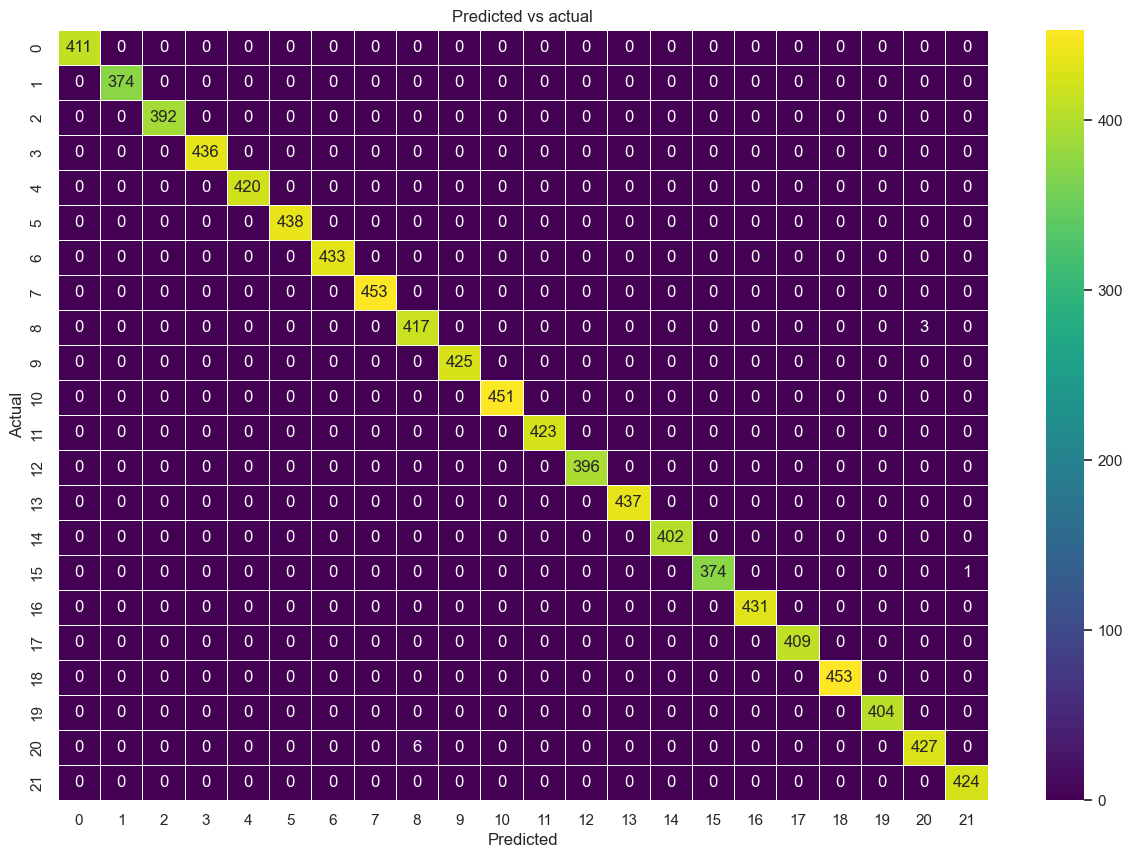

In [110]:
y_pred = RF.predict(x_test)
y_true = y_test

cm_rf = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_rf, annot=True, linewidth=0.5, fmt=".0f",  cmap='viridis', ax = ax)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Predicted vs actual')
plt.show()

### **Naive Bayes Classifier**

In [111]:
from sklearn.naive_bayes import GaussianNB
NaiveBayes = GaussianNB()

NaiveBayes.fit(x_train,y_train)

predicted_values = NaiveBayes.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes Accuracy is: ", x)

print(classification_report(y_test,predicted_values))

Naive Bayes Accuracy is:  0.9943722943722944
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       411
      banana       1.00      1.00      1.00       374
   blackgram       1.00      1.00      1.00       392
    chickpea       1.00      1.00      1.00       436
     coconut       1.00      1.00      1.00       420
      coffee       1.00      1.00      1.00       438
      cotton       1.00      1.00      1.00       433
      grapes       1.00      1.00      1.00       453
        jute       0.91      0.98      0.94       420
 kidneybeans       1.00      1.00      1.00       425
      lentil       1.00      1.00      1.00       451
       maize       1.00      1.00      1.00       423
       mango       1.00      1.00      1.00       396
   mothbeans       1.00      1.00      1.00       437
    mungbean       1.00      1.00      1.00       402
   muskmelon       1.00      1.00      1.00       375
      orange       1.00      1.00   

In [112]:
score = cross_val_score(NaiveBayes,features,target,cv=5)
print('Cross validation score: ',score)

Cross validation score:  [0.99480519 0.99664502 0.99534632 0.99480519 0.99534632]


In [113]:
nb_train_accuracy = NaiveBayes.score(x_train,y_train)
print("Training accuracy = ",NaiveBayes.score(x_train,y_train))

nb_test_accuracy = NaiveBayes.score(x_test,y_test)
print("Testing accuracy = ",NaiveBayes.score(x_test,y_test))

Training accuracy =  0.9956168831168831
Testing accuracy =  0.9943722943722944


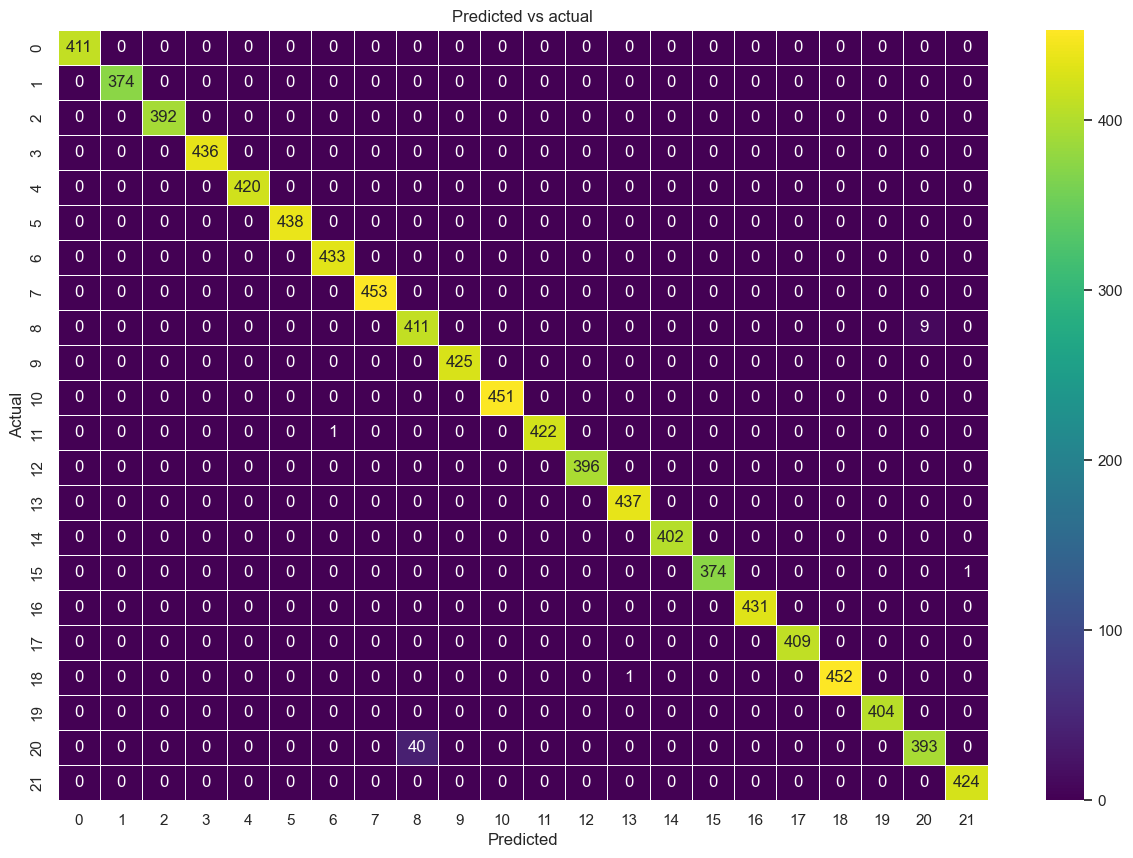

In [114]:
y_pred = NaiveBayes.predict(x_test)
y_true = y_test

cm_nb = confusion_matrix(y_true,y_pred)

f, ax = plt.subplots(figsize=(15,10))
sns.heatmap(cm_nb, annot=True, linewidth=0.5, fmt=".0f",  cmap='viridis', ax = ax)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Predicted vs actual')
plt.show()

### **Accuracy Comparision**

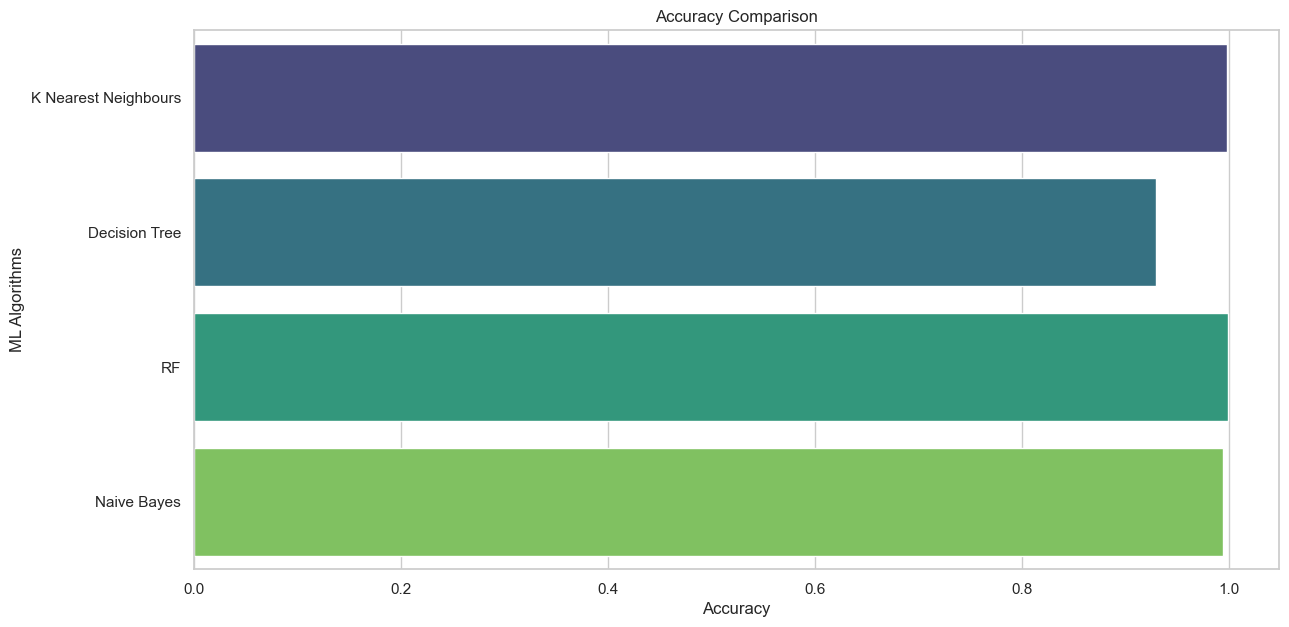

In [115]:
plt.figure(figsize=[14,7],dpi = 100, facecolor='white')
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('ML Algorithms')
sns.barplot(x = acc,y = model,palette='viridis')
plt.savefig('plot.png', dpi=300, bbox_inches='tight')

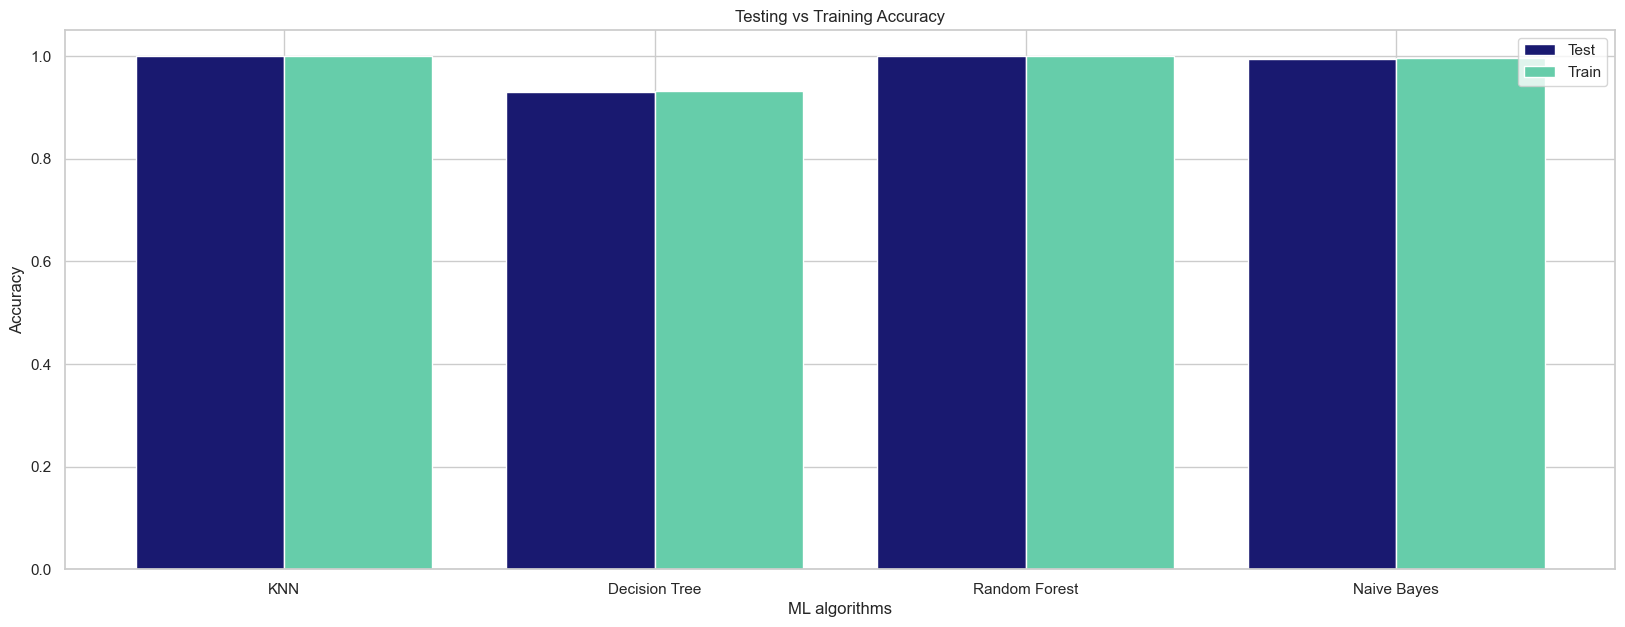

In [116]:
label = ['KNN', 'Decision Tree','Random Forest','Naive Bayes']
Test = [knn_test_accuracy, dt_test_accuracy,rf_test_accuracy,
        nb_test_accuracy]
Train = [knn_train_accuracy,  dt_train_accuracy, rf_train_accuracy,
         nb_train_accuracy]

f, ax = plt.subplots(figsize=(20,7))
X_axis = np.arange(len(label))
plt.bar(X_axis - 0.2,Test, 0.4, label = 'Test', color=('midnightblue'))
plt.bar(X_axis + 0.2,Train, 0.4, label = 'Train', color=('mediumaquamarine'))

plt.xticks(X_axis, label)
plt.xlabel("ML algorithms")
plt.ylabel("Accuracy")
plt.title("Testing vs Training Accuracy")
plt.legend()
plt.show()

In [117]:
def predict_crop_with_rf(nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall, model):

    input_data = np.array([[nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall]])
    prediction = model.predict(input_data)
    return prediction[0]

# Example usage with Random Forest model
crop_prediction_rf = predict_crop_with_rf(
    nitrogen=38,
    phosphorus=58,
    potassium=84,
    temperature=17.87,
    humidity=15.59,
    ph=5.86,
    rainfall=68.58,
    model=RF  # Use the trained Random Forest model
)

print(f"The recommended crop is: {crop_prediction_rf}")


The recommended crop is: chickpea


In [118]:
def predict_crop(nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall, model):

    input_data = np.array([[nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall]])
    prediction = model.predict(input_data)
    return prediction[0]

# Example usage with KNN model
crop_prediction = predict_crop(
    nitrogen=38,
    phosphorus=58,
    potassium=84,
    temperature=17.87,
    humidity=15.59,
    ph=5.86,
    rainfall=68.58,
    model=knn_1  # Use the trained model (knn_1)
)

print(f"The recommended crop is: {crop_prediction}")


The recommended crop is: chickpea


In [119]:
import pickle

# Save the Random Forest model
pickle.dump(RF, open('model.pkl', 'wb'))
print("Model saved successfully.")


Model saved successfully.
